In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cpu


数据集形状: (12330, 18)

前5行:
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10        

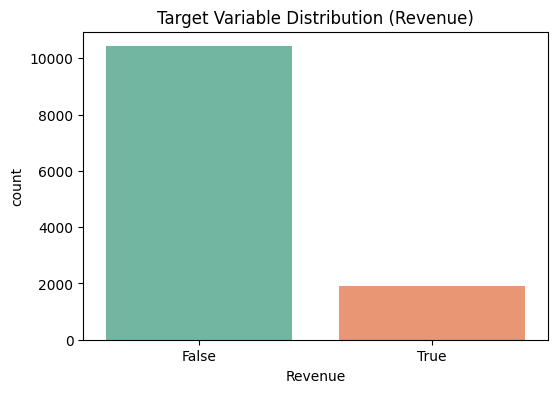

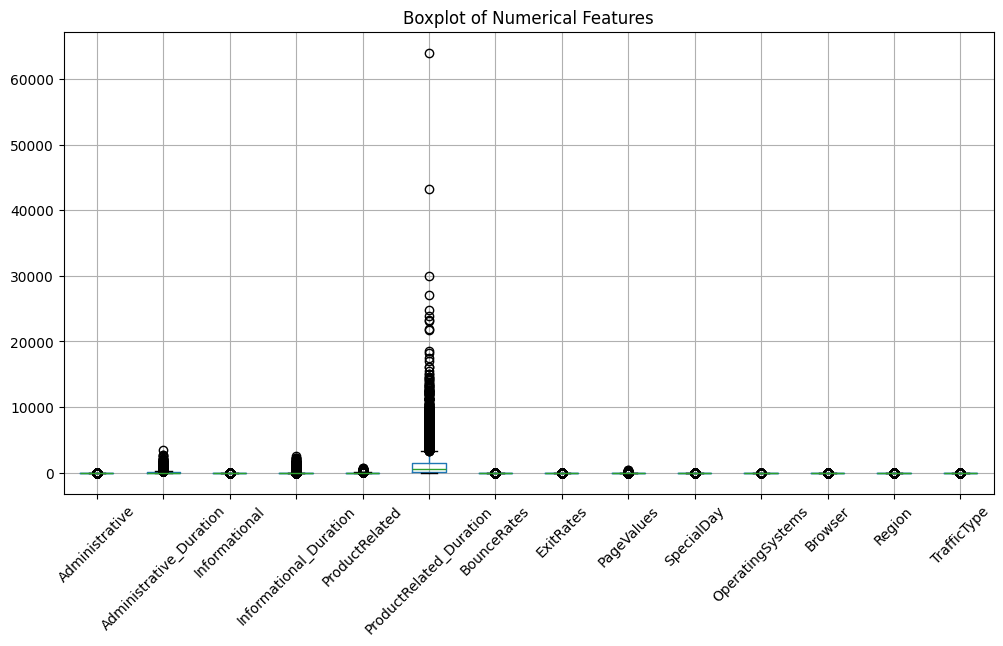

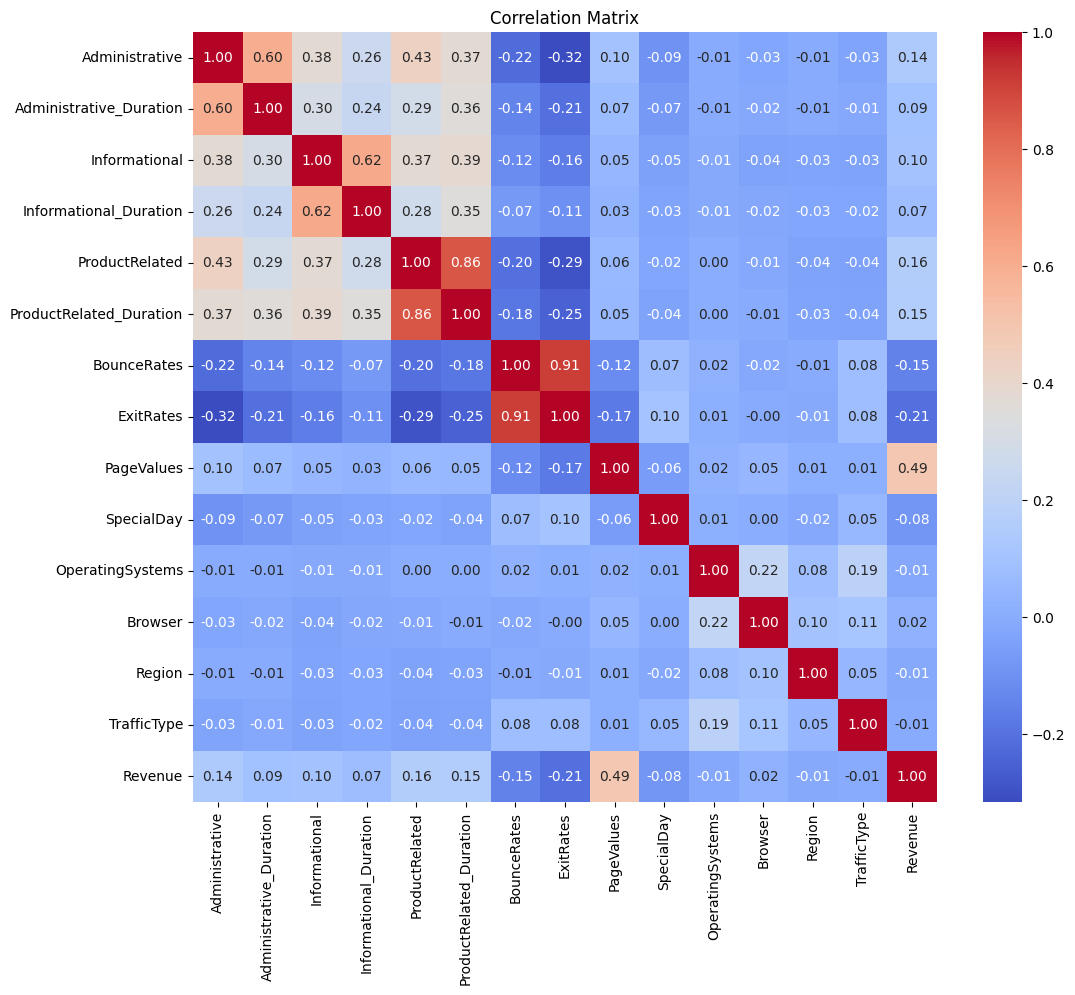

In [2]:
# 直接读取 shopping.csv
df = pd.read_csv('shopping.csv')
print("数据集形状:", df.shape)
print("\n前5行:")
print(df.head())

# ---- 数据概览 ----
print("\n列名:", df.columns.tolist())
print("\n数据类型:\n", df.dtypes)
print("\n缺失值:\n", df.isnull().sum())

# ---- 目标变量分布 ----
plt.figure(figsize=(6,4))
sns.countplot(x='Revenue', data=df, palette='Set2')
plt.title('Target Variable Distribution (Revenue)')
plt.savefig('target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- 数值特征分布 ----
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols.remove('Revenue') if 'Revenue' in num_cols else None

# 绘制箱线图查看异常值
plt.figure(figsize=(12, 6))
df[num_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot of Numerical Features')
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

# ---- 特征相关性热图 ----
plt.figure(figsize=(12, 10))
sns.heatmap(df[num_cols + ['Revenue']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
# 1. 删除缺失值（如果有）
df = df.dropna()

# 2. 分离特征和标签
X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)

# 3. 编码分类特征（使用 LabelEncoder）
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("分类列:", cat_cols)

le_dict = {}  # 保存编码器以备后续逆变换
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le

# 4. 处理布尔类型（如果有）
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

# 5. 确保所有特征都是数值
print("\n特征类型检查:")
print(X.dtypes.value_counts())

# 6. 划分训练+验证 和 测试集 (70% 训练+验证, 30% 测试)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

# 7. 从训练+验证中再划分训练集和验证集 (80% 训练, 20% 验证)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, random_state=SEED, stratify=y_train_val)

print(f"训练集: {X_train.shape[0]} 样本")
print(f"验证集: {X_val.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 8. 标准化（只使用训练集的统计量）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 保留DataFrame格式方便后续分析
X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\n预处理完成。")

分类列: ['Month', 'VisitorType']

特征类型检查:
int64      10
float64     7
Name: count, dtype: int64
训练集: 6904 样本
验证集: 1727 样本
测试集: 3699 样本

预处理完成。


In [4]:
class TabularDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features.values, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

BATCH_SIZE = 64
train_dataset = TabularDataset(X_train, y_train)
val_dataset = TabularDataset(X_val, y_val)
test_dataset = TabularDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [5]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))  # 输出层
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(-1)

input_dim = X_train.shape[1]
model = MLPClassifier(input_dim=input_dim, hidden_dims=[128, 64, 32], dropout_rate=0.3).to(device)
print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")

模型参数量: 13,121


In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    preds, truths = [], []
    for features, labels in loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds.extend((outputs > 0.5).int().cpu().numpy())
        truths.extend(labels.cpu().numpy())
    acc = accuracy_score(truths, preds)
    f1 = f1_score(truths, preds, zero_division=0)
    return total_loss / len(loader), acc, f1

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    preds, truths = [], []
    with torch.no_grad():
        for features, labels in loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            preds.extend((outputs > 0.5).int().cpu().numpy())
            truths.extend(labels.cpu().numpy())
    acc = accuracy_score(truths, preds)
    f1 = f1_score(truths, preds, zero_division=0)
    return total_loss / len(loader), acc, f1

In [7]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
# 移除 verbose 参数
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

EPOCHS = 100
PATIENCE = 20
best_val_loss = np.inf
patience_counter = 0
best_model_state = None

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS+1):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion)
    # 学习率调度
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    new_lr = optimizer.param_groups[0]['lr']
    if new_lr < old_lr:
        print(f"Epoch {epoch}: Learning rate reduced from {old_lr:.2e} to {new_lr:.2e}")
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 早停
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:2d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

# 加载最佳模型
model.load_state_dict(best_model_state)
print("训练结束，加载最佳验证集模型。")

Epoch 10 | Train Loss: 0.2602 | Train Acc: 0.8956 | Val Loss: 0.2544 | Val Acc: 0.8964
Epoch 20 | Train Loss: 0.2451 | Train Acc: 0.9011 | Val Loss: 0.2476 | Val Acc: 0.8987
Epoch 30 | Train Loss: 0.2437 | Train Acc: 0.9033 | Val Loss: 0.2423 | Val Acc: 0.9010
Epoch 40: Learning rate reduced from 1.00e-03 to 5.00e-04
Epoch 40 | Train Loss: 0.2368 | Train Acc: 0.9051 | Val Loss: 0.2401 | Val Acc: 0.9010
Early stopping at epoch 49
训练结束，加载最佳验证集模型。


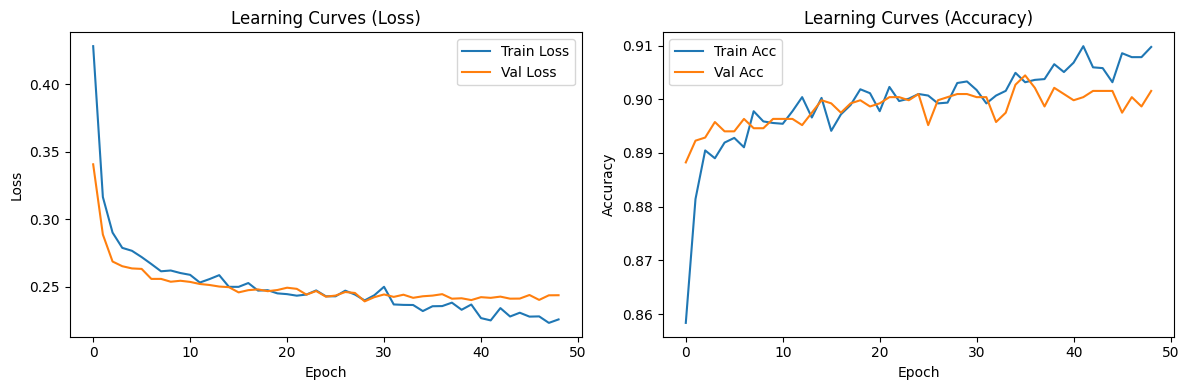

In [8]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curves (Loss)')

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curves (Accuracy)')
plt.tight_layout()
plt.savefig('mlp_learning_curves.png', dpi=300)
plt.show()

In [9]:
test_loss, test_acc, test_f1 = evaluate(model, test_loader, criterion)

# 获取预测概率和类别
model.eval()
all_probs = []
all_preds = []
all_truths = []
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        outputs = model(features)
        probs = outputs.cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_truths.extend(labels.cpu().numpy())

test_precision = precision_score(all_truths, all_preds, zero_division=0)
test_recall = recall_score(all_truths, all_preds, zero_division=0)
test_auc = roc_auc_score(all_truths, all_probs)

mlp_metrics = {
    'Accuracy': test_acc,
    'F1': test_f1,
    'Precision': test_precision,
    'Recall': test_recall,
    'AUC': test_auc
}
print("MLP Test Metrics:")
for k, v in mlp_metrics.items():
    print(f"  {k}: {v:.4f}")

MLP Test Metrics:
  Accuracy: 0.8935
  F1: 0.6297
  Precision: 0.6809
  Recall: 0.5857
  AUC: 0.9059


In [10]:
logreg = LogisticRegression(max_iter=1000, random_state=SEED)
logreg.fit(X_train, y_train)
y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

logreg_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_logreg),
    'F1': f1_score(y_test, y_pred_logreg, zero_division=0),
    'Precision': precision_score(y_test, y_pred_logreg, zero_division=0),
    'Recall': recall_score(y_test, y_pred_logreg, zero_division=0),
    'AUC': roc_auc_score(y_test, y_proba_logreg)
}
print("Logistic Regression (Baseline) Metrics:")
for k, v in logreg_metrics.items():
    print(f"  {k}: {v:.4f}")

Logistic Regression (Baseline) Metrics:
  Accuracy: 0.8832
  F1: 0.4965
  Precision: 0.7448
  Recall: 0.3724
  AUC: 0.8722


In [11]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'F1': f1_score(y_test, y_pred_xgb, zero_division=0),
    'Precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'Recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'AUC': roc_auc_score(y_test, y_proba_xgb)
}
print("XGBoost Metrics:")
for k, v in xgb_metrics.items():
    print(f"  {k}: {v:.4f}")

XGBoost Metrics:
  Accuracy: 0.8954
  F1: 0.6297
  Precision: 0.6956
  Recall: 0.5752
  AUC: 0.9171


=== 模型性能对比 ===
                            Model  Accuracy  F1 Score  Precision  Recall  \
0  Logistic Regression (Baseline)    0.8832    0.4965     0.7448  0.3724   
1            MLP (Neural Network)    0.8935    0.6297     0.6809  0.5857   
2                         XGBoost    0.8954    0.6297     0.6956  0.5752   

      AUC  
0  0.8722  
1  0.9059  
2  0.9171  


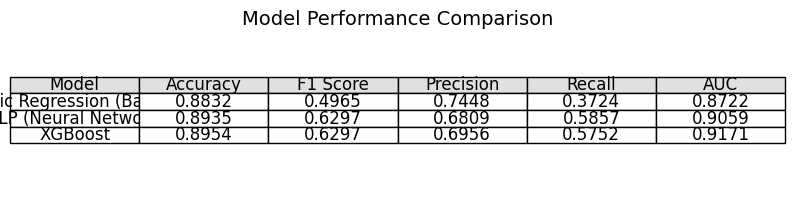

In [12]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (Baseline)', 'MLP (Neural Network)', 'XGBoost'],
    'Accuracy': [logreg_metrics['Accuracy'], mlp_metrics['Accuracy'], xgb_metrics['Accuracy']],
    'F1 Score': [logreg_metrics['F1'], mlp_metrics['F1'], xgb_metrics['F1']],
    'Precision': [logreg_metrics['Precision'], mlp_metrics['Precision'], xgb_metrics['Precision']],
    'Recall': [logreg_metrics['Recall'], mlp_metrics['Recall'], xgb_metrics['Recall']],
    'AUC': [logreg_metrics['AUC'], mlp_metrics['AUC'], xgb_metrics['AUC']]
})

print("=== 模型性能对比 ===")
print(comparison_df.round(4))

# 保存为表格图片
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=comparison_df.round(4).values,
                 colLabels=comparison_df.columns,
                 loc='center',
                 cellLoc='center',
                 colColours=['#e0e0e0']*len(comparison_df.columns))
table.auto_set_font_size(False)
table.set_fontsize(12)
plt.title('Model Performance Comparison', fontsize=14)
plt.savefig('model_comparison_table.png', dpi=300, bbox_inches='tight')
plt.show()

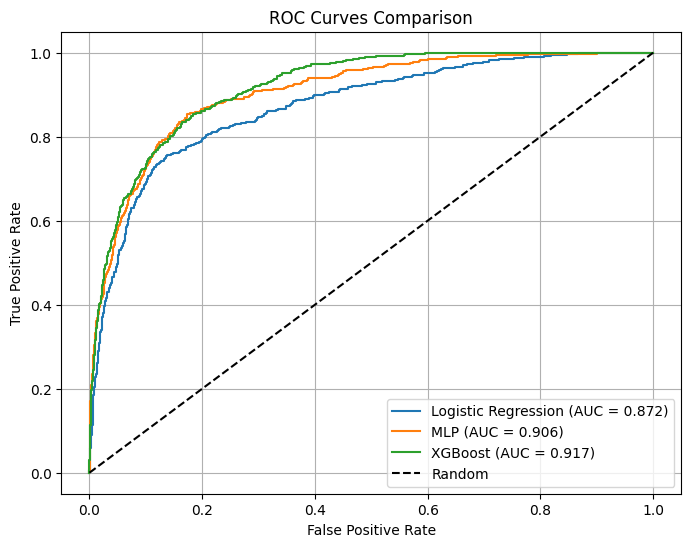

In [13]:
plt.figure(figsize=(8, 6))
for name, probs in [('Logistic Regression', y_proba_logreg),
                    ('MLP', all_probs),
                    ('XGBoost', y_proba_xgb)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid(True)
plt.savefig('roc_curves.png', dpi=300)
plt.show()

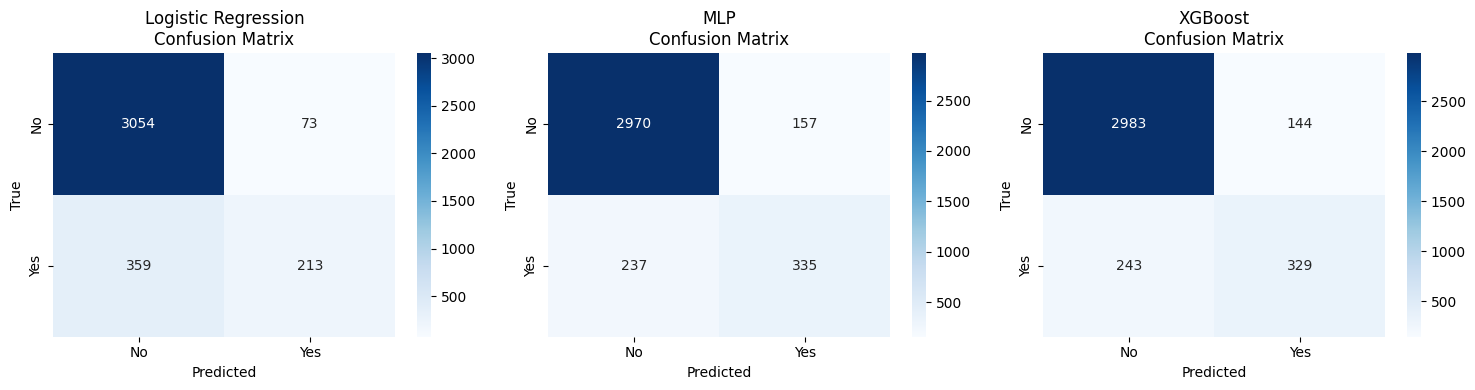

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models_data = [
    ('Logistic Regression', y_pred_logreg),
    ('MLP', all_preds),
    ('XGBoost', y_pred_xgb)
]
for ax, (name, preds) in zip(axes, models_data):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

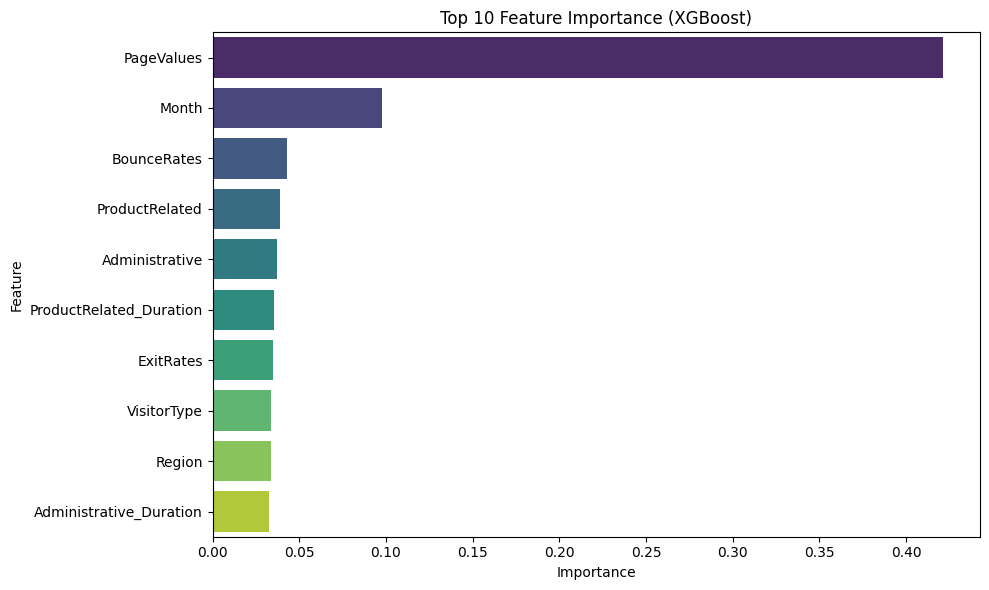

In [15]:
# XGBoost 特征重要性
importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=300)
plt.show()

In [16]:
# 获取测试集所有预测结果（与之前对应）
error_indices = [i for i, (true, pred) in enumerate(zip(all_truths, all_preds)) if true != pred]
print(f"MLP 错误样本数: {len(error_indices)} / {len(all_truths)} ({len(error_indices)/len(all_truths)*100:.2f}%)")

# 将错误样本的特征还原（标准化前的值）
X_test_original = scaler.inverse_transform(X_test_scaled)
X_test_original_df = pd.DataFrame(X_test_original, columns=X.columns)

# 展示前5个错误样本的特征（真实值和预测值）
if len(error_indices) > 0:
    print("\n前5个错误样本（特征子集）:")
    sample_features = X_test_original_df.iloc[error_indices[:5]].round(2)
    sample_features['True'] = [all_truths[i] for i in error_indices[:5]]
    sample_features['Pred'] = [all_preds[i] for i in error_indices[:5]]
    print(sample_features[['True', 'Pred'] + X.columns[:5].tolist()])  # 显示部分特征

MLP 错误样本数: 394 / 3699 (10.65%)

前5个错误样本（特征子集）:
    True  Pred  Administrative  Administrative_Duration  Informational  \
3    1.0     0             0.0                     0.00            0.0   
13   1.0     0             0.0                     0.00            0.0   
22   1.0     0            11.0                   424.48            5.0   
24   1.0     0            11.0                   162.75            3.0   
35   1.0     0             3.0                    67.75            0.0   

    Informational_Duration  ProductRelated  
3                     0.00            39.0  
13                    0.00            89.0  
22                  185.75            76.0  
24                   67.50            80.0  
35                    0.00             2.0  


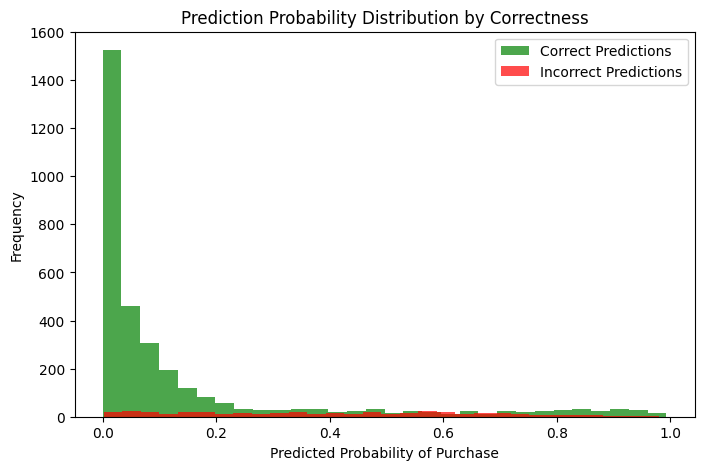

In [17]:
# 将概率分为正确预测和错误预测
correct_probs = [all_probs[i] for i in range(len(all_probs)) if all_truths[i] == all_preds[i]]
error_probs = [all_probs[i] for i in range(len(all_probs)) if all_truths[i] != all_preds[i]]

plt.figure(figsize=(8, 5))
plt.hist(correct_probs, bins=30, alpha=0.7, label='Correct Predictions', color='green')
plt.hist(error_probs, bins=30, alpha=0.7, label='Incorrect Predictions', color='red')
plt.xlabel('Predicted Probability of Purchase')
plt.ylabel('Frequency')
plt.title('Prediction Probability Distribution by Correctness')
plt.legend()
plt.savefig('prob_distribution.png', dpi=300)
plt.show()

In [18]:
# 这里列出可调超参数范围，实际调优可以在报告里描述
param_grid = {
    'hidden_dims': [[128, 64], [128, 64, 32], [256, 128, 64]],
    'dropout_rate': [0.2, 0.3, 0.4],
    'learning_rate': [1e-3, 5e-4, 1e-4],
    'batch_size': [32, 64]
}
print("推荐搜索的超参数范围:")
for k, v in param_grid.items():
    print(f"  {k}: {v}")

# 当前模型使用的参数
print("\n当前模型使用的超参数:")
print(f"  hidden_dims: [128, 64, 32]")
print(f"  dropout_rate: 0.3")
print(f"  learning_rate: 1e-3 (初始)")
print(f"  batch_size: 64")
print(f"  使用 ReduceLROnPlateau (factor=0.5, patience=10) 动态调整学习率")

推荐搜索的超参数范围:
  hidden_dims: [[128, 64], [128, 64, 32], [256, 128, 64]]
  dropout_rate: [0.2, 0.3, 0.4]
  learning_rate: [0.001, 0.0005, 0.0001]
  batch_size: [32, 64]

当前模型使用的超参数:
  hidden_dims: [128, 64, 32]
  dropout_rate: 0.3
  learning_rate: 1e-3 (初始)
  batch_size: 64
  使用 ReduceLROnPlateau (factor=0.5, patience=10) 动态调整学习率
